In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
data = pd.read_csv("studentVle.csv")
data.head()


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [29]:
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


,id_student,id_site,date,sum_click
count,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
mean,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00
max,2.698588e+06,1.049562e+06,2.690000e+02,6.977000e+03


In [30]:
#data cleaning
data.isnull().sum()

data = data.dropna()
data = data.drop_duplicates()


In [31]:
#data transformonati
data['week'] = data['date'] // 7

weekly_activity = data.groupby(['id_student', 'week'])['sum_click'].sum().reset_index() #data aggregation
weekly_activity.head()


,id_student,week,sum_click
0,6516,-4,110
1,6516,-3,48
2,6516,-2,2
3,6516,-1,89
4,6516,0,229


In [32]:
#feature construction
features = weekly_activity.groupby('id_student').agg(
    avg_activity=('sum_click', 'mean'),
    max_activity=('sum_click', 'max'),
    active_weeks=('week', 'count')
).reset_index()

features.head()


,id_student,avg_activity,max_activity,active_weeks
0,6516,69.615385,229,39
1,8462,37.823529,153,17
2,11391,34.148148,183,27
3,23629,13.909091,35,11
4,23698,32.814815,132,27


In [33]:
#early warning signs (inactivity abalysis)
weekly_activity['inactive'] = weekly_activity['sum_click'] == 0

inactivity_gap = weekly_activity.groupby('id_student')['inactive'].sum().reset_index()
inactivity_gap.rename(columns={'inactive': 'inactive_weeks'}, inplace=True)

inactivity_gap.head()



,id_student,inactive_weeks
0,6516,0
1,8462,0
2,11391,0
3,23629,0
4,23698,0


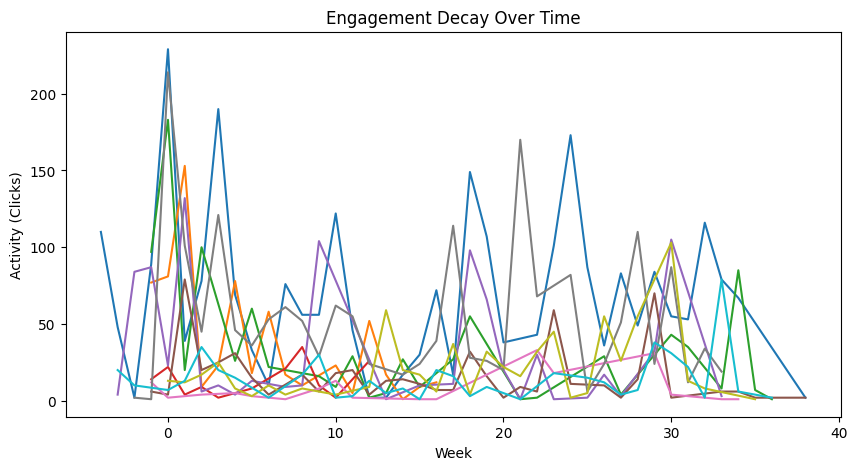

In [34]:
#visualization
sample_users = weekly_activity['id_student'].unique()[:10]

plt.figure(figsize=(10,5))
for user in sample_users:
    user_data = weekly_activity[weekly_activity['id_student'] == user]
    plt.plot(user_data['week'], user_data['sum_click'])

plt.xlabel("Week")
plt.ylabel("Activity (Clicks)")
plt.title("Engagement Decay Over Time")
plt.show()


In [35]:
#FEATURE ADOPTION VS ABANDONMENT
# feature_usage = data.groupby('id_site')['id_student'].nunique().reset_index()
# feature_usage.columns = ['feature', 'user_count']

# feature_usage.sort_values(by='user_count', ascending=False).head()
feature_weekly = (
    data.groupby(['id_site', 'week'])['id_student']
    .nunique()
    .reset_index(name='user_count')
)



In [36]:
feature_trend = (
    feature_weekly.groupby('id_site')
    .agg(
        first_week_usage=('user_count', 'first'),
        last_week_usage=('user_count', 'last'),
        avg_usage=('user_count', 'mean')
    )
    .reset_index()
)


In [37]:
#decay ratio
feature_trend['decay_ratio'] = (
    feature_trend['last_week_usage'] / feature_trend['first_week_usage']
)


In [38]:
#classify features
def classify_feature(row):
    if row['decay_ratio'] < 0.5:
        return 'Abandoned'
    elif row['decay_ratio'] < 0.9:
        return 'Declining'
    else:
        return 'Adopted'

feature_trend['feature_status'] = feature_trend.apply(classify_feature, axis=1)


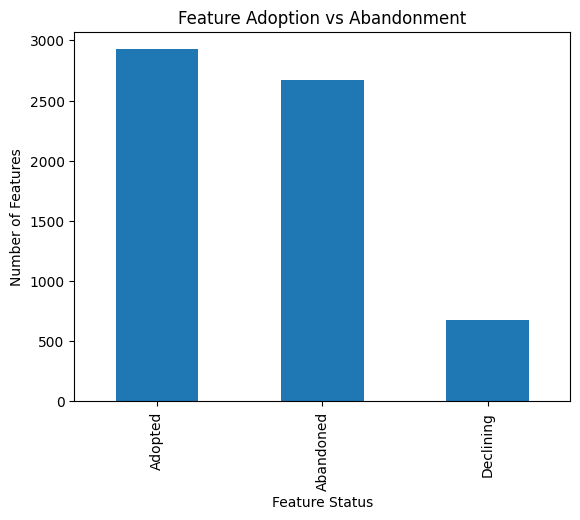

In [39]:
#visuLze
feature_trend['feature_status'].value_counts().plot(kind='bar')
plt.title("Feature Adoption vs Abandonment")
plt.xlabel("Feature Status")
plt.ylabel("Number of Features")
plt.show()


In [40]:
#FEATURE USAGE VISUALIZATION
# top_features = feature_usage.head(10)

# plt.figure(figsize=(8,5))
# sns.barplot(x='user_count', y='feature', data=top_features)
# plt.title("Top Adopted Features")
# plt.xlabel("Number of Users")
# plt.ylabel("Feature")
# plt.show()



In [41]:
#simple cluterin
from sklearn.cluster import KMeans

X = features[['avg_activity', 'active_weeks']]
kmeans = KMeans(n_clusters=2, random_state=0)
features['cluster'] = kmeans.fit_predict(X)

features.head()


,id_student,avg_activity,max_activity,active_weeks,cluster
0,6516,69.615385,229,39,0
1,8462,37.823529,153,17,0
2,11391,34.148148,183,27,0
3,23629,13.909091,35,11,0
4,23698,32.814815,132,27,0
